INFO:root:Initialized DynamicalOrderDisorder analysis for 0.0 with 13 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for 1.0 with 13 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for 2.0 with 13 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for 3.0 with 13 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for 4.0 with 13 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for 5.0 with 13 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for 0.0 with 13 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for 1.0 with 7 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for 2.0 with 6 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for 5.0 with 5 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for 6.0 with 9 CSV files
INFO:root:Initialized DynamicalOrderDisorder analysis for 7.0 with 5 CSV files
INFO:root:Initialized DynamicalOrderDisorder 

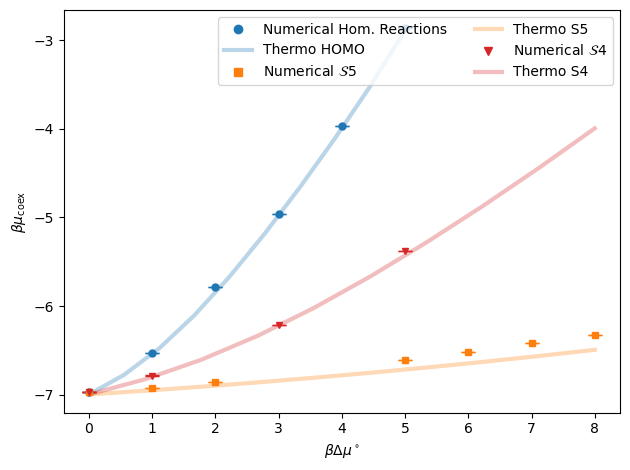

In [13]:
import nesspy_analysis as npa
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit
import pandas as pd

dmus: list[float] = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
paths: list[Path] = [Path("/Volumes/2025/research_nov_2025_data/ML_F0_D0_K1"),
                     Path("/Volumes/2025/research_nov_2025_data/homo/ML_F0_D1_K1"),
                     Path("/Volumes/2025/research_nov_2025_data/homo/ML_F0_D2_K1"),
                     Path("/Volumes/2025/research_nov_2025_data/homo/ML_F0_D3_K1"),
                     Path("/Volumes/2025/research_nov_2025_data/homo/ML_F0_D4_K1"),
                     Path("/Volumes/2025/research_nov_2025_data/homo/ML_F0_D5_K1")
    
]

data_dic_homo = {'dmu': [], 'muc': [],'dmuc': []}

for dmu, path in zip(dmus, paths):
    analysis = npa.DynamicalOrderDisorder(dmu, path)
    thermos = npa.Thermos(dmu=dmu, method="HOMO", fres=0.0, k=1.0)
    data = analysis.get_data()
    data = data.sort_values(by=["mu"])
    mu0, dmu0 = analysis.calculate_zero_growth_speed()
    data_dic_homo['dmu'].append(dmu)
    data_dic_homo['muc'].append(mu0)
    data_dic_homo['dmuc'].append(dmu0)
    plt.errorbar(dmu, mu0, yerr=dmu0, fmt='o', capsize=5, color="tab:blue", ms=5,
                 label="Numerical Hom. Reactions")

df = pd.DataFrame(data_dic_homo)
df.to_csv("homo_data.csv")

from scipy.optimize import fsolve
sol = -7.0
data = {'dmu': [], 'sol': []}
for dmu in np.linspace(0, 5, 10):
    thermos = npa.Thermos(dmu=dmu, method="HOMO", fres=0.0, k=1.0)
    sol = fsolve(npa.calculate_dphi, sol, args=thermos)[0]
    data['dmu'].append(dmu)
    data['sol'].append(sol)
plt.plot(data['dmu'], data['sol'], color="tab:blue", lw=3, ls='solid', ms=0, alpha=0.3)

df = pd.DataFrame(data)
df.to_csv("homo_theory.csv")


dmus: list[float] = [0.0, 1.0, 2.0, 5.0, 6.0, 7.0, 8.0]
paths: list[Path] = [   Path("/Volumes/2025/research_nov_2025_data/ML_F0_D0_K1"),
                        Path("/Volumes/2025/20x80_coex/20x80_F0_D1_K1_SCHEME_6"),
                        Path("/Volumes/2025/20x80_coex/20x80_F0_D2_K1_SCHEME_6"),
                        Path("/Volumes/2025/20x80_coex/20x80_F0_D5_K1_SCHEME_6"),
                        Path("/Volumes/2025/20x80_coex/20x80_F0_D6_K1_SCHEME_6"),
                        Path("/Volumes/2025/20x80_coex/20x80_F0_D7_K1_SCHEME_6"),
                        Path("/Volumes/2025/20x80_coex/20x80_F0_D8_K1_SCHEME_6"),    
]

data_dic_homo = {'dmu': [], 'muc': [],'dmuc': []}

for dmu, path in zip(dmus, paths):
    analysis = npa.DynamicalOrderDisorder(dmu, path)
    thermos = npa.Thermos(dmu=dmu, method="SCHEME6", fres=0.0, k=1.0)
    data = analysis.get_data()
    data = data.sort_values(by=["mu"])
    mu0, dmu0 = analysis.calculate_zero_growth_speed()
    data_dic_homo['dmu'].append(dmu)
    data_dic_homo['muc'].append(mu0)
    data_dic_homo['dmuc'].append(dmu0)
    plt.errorbar(dmu, mu0, yerr=dmu0, fmt='s', capsize=5, color="tab:orange", ms=5,
                 label=r"Numerical $\mathcal{S}5$")
    
df = pd.DataFrame(data_dic_homo)
df.to_csv("s6_coex.csv")

sol = -7.0
data = {'dmu': [], 'sol': []}
for dmu in np.linspace(0, 8, 10):
    thermos = npa.Thermos(dmu=dmu, method="SCHEME6", fres=0.0, k=1.0)
    sol = fsolve(npa.calculate_dphi, sol, args=thermos)[0]
    data['dmu'].append(dmu)
    data['sol'].append(sol)
plt.plot(data['dmu'], data['sol'], color="tab:orange", lw=3, ls='solid', ms=0, alpha=0.3)

df = pd.DataFrame(data)
df.to_csv("s6_theory.csv")





sol = -7.0
data = {'dmu': [], 'sol': []}
for dmu in np.linspace(0, 8, 10):
    thermos = npa.Thermos(dmu=dmu, method="SCHEME7", fres=0.0, k=1.0)
    sol = fsolve(npa.calculate_dphi, sol, args=thermos)[0]
    data['dmu'].append(dmu)
    data['sol'].append(sol)
plt.plot(data['dmu'], data['sol'], color="tab:red", lw=3, ls='solid', ms=0, alpha=0.3)

df = pd.DataFrame(data)
df.to_csv("s7_theory.csv")

dmus: list[float] = [0.0, 1.0, 3.0, 5.0]
paths: list[Path] = [   Path("/Volumes/2025/research_nov_2025_data/ML_F0_D0_K1"),
                        Path("/Volumes/2025/20x80_coex/ML_F0.0_D1.0_K1.0_SCHEME_7.0"),  
                        Path("/Volumes/2025/20x80_coex/ML_F0.0_D3.0_K1.0_SCHEME_7.0"),
                        Path("/Volumes/2025/20x80_coex/ML_F0.0_D5.0_K1.0_SCHEME_7.0"),
]

data_dic_homo = {'dmu': [], 'muc': [],'dmuc': []}

for dmu, path in zip(dmus, paths):
    analysis = npa.DynamicalOrderDisorder(dmu, path)
    thermos = npa.Thermos(dmu=dmu, method="SCHEME7", fres=0.0, k=1.0)
    data = analysis.get_data()
    data = data.sort_values(by=["mu"])
    mu0, dmu0 = analysis.calculate_zero_growth_speed()
    data_dic_homo['dmu'].append(dmu)
    data_dic_homo['muc'].append(mu0)
    data_dic_homo['dmuc'].append(dmu0)
    plt.errorbar(dmu, mu0, yerr=dmu0, fmt='v', capsize=5, color="tab:red", ms=5,
                 label=r"Numerical $\mathcal{S}4$")
df = pd.DataFrame(data_dic_homo)
df.to_csv("s7_coex.csv")

plt.xlabel(r'$\beta \Delta \mu^\circ$')
plt.ylabel(r'$\beta \mu_\mathrm{coex}$')

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='tab:blue', linestyle='None', markersize=6,
           label='Numerical Hom. Reactions'),
    Line2D([0], [0], color='tab:blue', lw=3, alpha=0.3, label='Thermo HOMO'),
    Line2D([0], [0], marker='s', color='tab:orange', linestyle='None', markersize=6,
           label=r'Numerical $\mathcal{S}5$'),
    Line2D([0], [0], color='tab:orange', lw=3, alpha=0.3, label='Thermo S5'),
    Line2D([0], [0], marker='v', color='tab:red', linestyle='None', markersize=6,
           label=r'Numerical $\mathcal{S}4$'),
    Line2D([0], [0], color='tab:red', lw=3, alpha=0.3, label='Thermo S4'),
]

plt.legend(handles=legend_elements, loc='best', frameon=True, fontsize=10, ncol=2, handlelength=2)
plt.tight_layout()